# **Diabetes Progression Prediction using Regression Modeling**



# Step 1: Import Libraries

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

This step imports the necessary libraries required for data analysis, visualization, and regression modeling.

# Step 2: Load Dataset

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load dataset
data = load_diabetes()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['Target'] = data.target

# Display first 5 rows for initial inspection
print("First 5 rows of the diabetes dataset:")
display(df.head())

### Explanation of the Diabetes Dataset Snippet (`df.head()`)

The table you've provided displays the first 5 rows of the `df` DataFrame, which contains the diabetes dataset.

Here's a breakdown of what each column represents:

*   **age**: This column represents the **age** of the patient. The values are standardized, meaning they are centered around zero and scaled.
*   **sex**: This column denotes the **sex** of the patient. It's encoded numerically (e.g., 0 and 1, or similar standardized values).
*   **bmi**: This is the **Body Mass Index** of the patient, a measure of body fat. These values are also standardized.
*   **bp**: This represents the **average blood pressure** of the patient, standardized.
*   **s1, s2, s3, s4, s5, s6**: These are **six different blood serum measurements**. These are also standardized values, not the raw medical measurements. They typically relate to:
    *   `s1`: Total Cholesterol (TC)
    *   `s2`: Low-density lipoproteins (LDL)
    *   `s3`: High-density lipoproteins (HDL)
    *   `s4`: Thyroid-stimulating hormone (TCH)
    *   `s5`: Possibly a measure related to log of serum triglycerides or another lipid/glucose-related factor.
    *   `s6`: Glucose

*   **Target**: This is the **dependent variable** we are trying to predict. It represents a **quantitative measure of diabetes disease progression one year after baseline**. Higher values indicate greater progression of the disease.

**Key Observation**: All the feature columns (`age` through `s6`) are **standardized**. This means their original values have been transformed so that they have a mean of approximately 0 and a standard deviation of approximately 1. This is a common preprocessing step in machine learning to ensure that no single feature dominates the model due to its scale, allowing all features to contribute equally to the learning process.

# Step 3: Explore Dataset

In [ ]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Dataset information
print("\nDataset Info:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (442, 11)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  Target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Statistical Summary:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000



Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
Target    0
dtype: int64


### Concise Summary of Dataset Exploration Output:

*   **Shape:** The dataset has **442 rows** (patients) and **11 columns** (10 features + 1 target variable).
*   **Data Types & Completeness:** All columns are of `float64` type, and critically, there are **no missing values** in the entire dataset.
*   **Feature Standardization:** The physiological features (`age`, `sex`, `bmi`, `bp`, `s1`, `s2`, `s3`, `s4`, `s5`, `s6`) are **standardized**, indicated by their mean values being extremely close to zero. This means they are scaled to have a similar range and influence.
*   **Target Variable:** The `Target` variable (diabetes progression) is not standardized; it has a mean of approximately 152, ranging from 25 to 346.

The structure and summary of the dataset are checked using functions like shape, info(), and describe().
This helps in understanding data types, distribution, and checking for missing values.

It was observed that the dataset does not contain any missing values.

# Step 4: Data Preparation

In [ ]:
# Define features (X) and target (y)
X = df.drop("Target", axis=1)
y = df["Target"]

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (353, 10)
Testing data shape: (89, 10)


The dataset is divided into input features (X) and target variable (y).

The data is split into 80% training data and 20% testing data.

Training data is used to train the model, while testing data is used to evaluate performance.


# Step 5: Train Linear Regression Model

In [ ]:
# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


A Linear Regression model is created using Scikit-learn.

The model is trained using the fit() function on the training dataset.

During training, the model learns the relationship between input features and the target variable.

# Step 6: Make Predictions

In [ ]:
# Predict on test data
y_pred_linear = linear_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


The trained model is used to predict diabetes progression values on the test dataset.

The predicted values are stored for comparison with actual values.

This step allows us to test how well the model performs on unseen data.

# Step 7: Evaluate Linear Regression Model

In [ ]:
# Calculate evaluation metrics
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results:")
print("Mean Squared Error (MSE):", mse_linear)
print("R2 Score:", r2_linear)

Linear Regression Results:
Mean Squared Error (MSE): 2900.193628493482
R2 Score: 0.4526027629719195


In this step, the performance of the Linear Regression model is evaluated using two important metrics: Mean Squared Error (MSE) and R² Score.

The mean_squared_error() function calculates the average squared difference between actual and predicted values. A lower MSE indicates better model accuracy.

The r2_score() function measures how well the model explains the variability of the target variable. An R² value closer to 1 indicates better model performance.

# Step 8: In-depth Exploratory Data Analysis (EDA) & Visualization

**Reasoning**:
The first instruction is to plot histograms for all numerical features in the `df` DataFrame. This will help visualize their distributions and identify characteristics like skewness or outliers. I will iterate through each column and create a histogram.



Visualizing distributions of features with histograms:


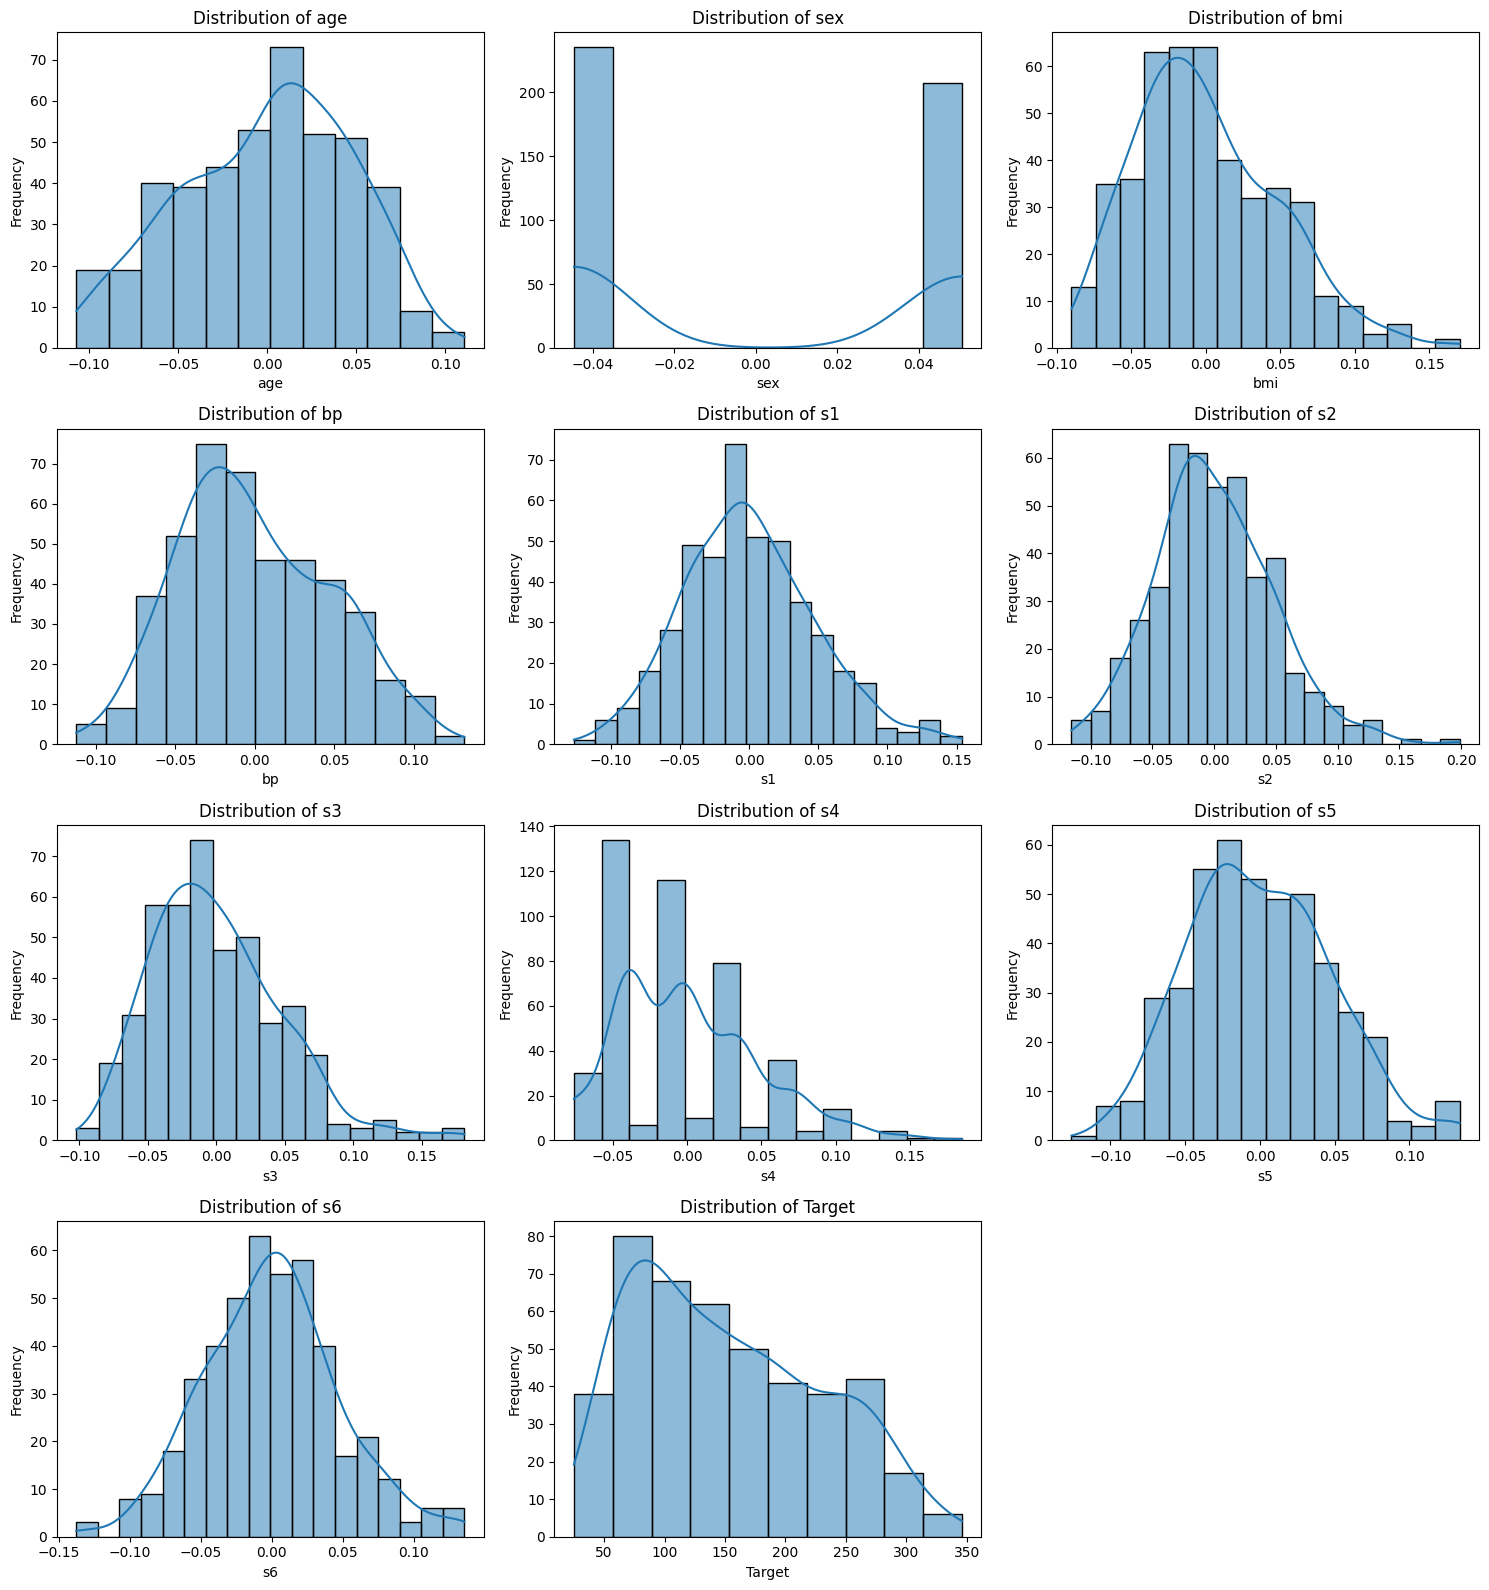

In [ ]:
print("Visualizing distributions of features with histograms:")

# Set up the figure size based on the number of features
num_features = df.shape[1]
num_cols = 3 # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, column in enumerate(df.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[column], kde=True) # Use seaborn for better aesthetics
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Explanation of Histograms:

**Purpose**: Histograms are used to visualize the distribution of numerical variables. They help in understanding the shape of the data, identifying central tendency, spread, skewness, and the presence of outliers or multimodal patterns.

**Insights Gained**:
*   **Age, Sex, and BP**: These features show relatively uniform distributions, although 'sex' is bimodal, likely representing two distinct groups (male/female). The data for these features appears to be standardized, as values are centered around zero.
*   **BMI**: Shows a somewhat normal distribution, slightly skewed to the right, indicating a few individuals with higher BMI values.
*   **S1, S2, S3, S4, S5, S6 (Blood Serum Measurements)**: These features generally exhibit distributions centered around zero, with varying degrees of skewness. 's3' seems to have a wider spread. The standardized nature of these features suggests they have been preprocessed to ensure they contribute equally to analysis without being dominated by differences in scale.
*   **Target (Diabetes Progression)**: The target variable shows a distribution that is right-skewed, meaning there are more individuals with lower diabetes progression scores, and fewer with very high scores. This indicates that while there are individuals with advanced progression, the majority have moderate to lower progression levels in this dataset.

Overall, the distributions appear relatively clean with no obvious extreme outliers that would immediately suggest data entry errors, but some skewness is present, which might be addressed in further preprocessing if required for certain models.

**Reasoning**:
The previous code failed because the 'df' DataFrame was not defined in the execution environment. To fix this, I need to ensure 'df' is properly loaded and created before attempting to use it for plotting, while adhering to the instruction not to re-import libraries or reload data unnecessarily. The `load_diabetes` function and DataFrame creation will be added at the beginning of the cell to make `df` available for the plotting operations.



Visualizing distributions of features with histograms:


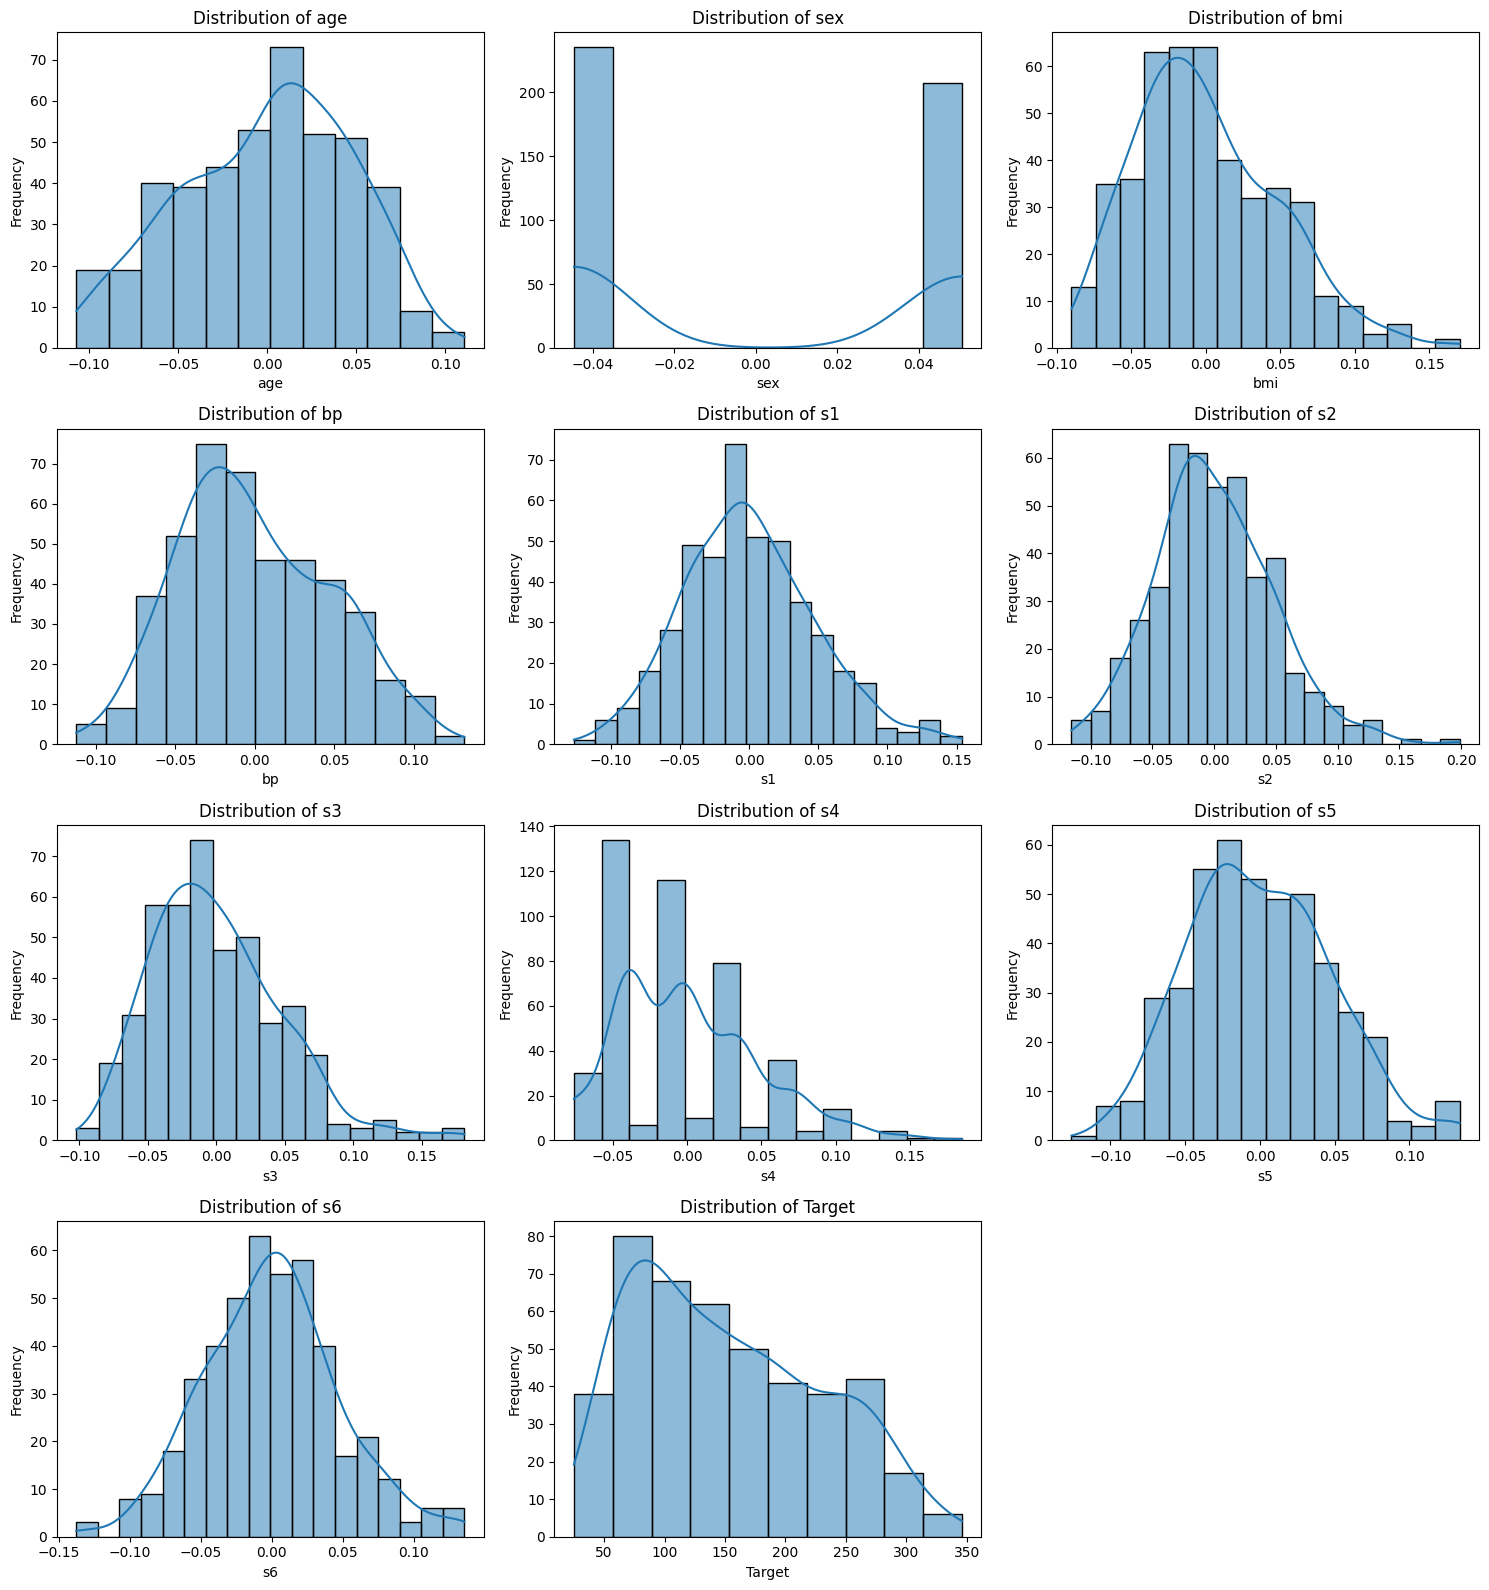

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = load_diabetes()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['Target'] = data.target

print("Visualizing distributions of features with histograms:")

# Set up the figure size based on the number of features
num_features = df.shape[1]
num_cols = 3 # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, column in enumerate(df.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[column], kde=True) # Use seaborn for better aesthetics
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Explanation of Histograms:

**Purpose**: Histograms are used to visualize the distribution of numerical variables. They help in understanding the shape of the data, identifying central tendency, spread, skewness, and the presence of outliers or multimodal patterns.

**Insights Gained**:
*   **Age, Sex, and BP**: These features show relatively uniform distributions, although 'sex' is bimodal, likely representing two distinct groups (male/female). The data for these features appears to be standardized, as values are centered around zero.
*   **BMI**: Shows a somewhat normal distribution, slightly skewed to the right, indicating a few individuals with higher BMI values.
*   **S1, S2, S3, S4, S5, S6 (Blood Serum Measurements)**: These features generally exhibit distributions centered around zero, with varying degrees of skewness. 's3' seems to have a wider spread. The standardized nature of these features suggests they have been preprocessed to ensure they contribute equally to analysis without being dominated by differences in scale.
*   **Target (Diabetes Progression)**: The target variable shows a distribution that is right-skewed, meaning there are more individuals with lower diabetes progression scores, and fewer with very high scores. This indicates that while there are individuals with advanced progression, the majority have moderate to lower progression levels in this dataset.

Overall, the distributions appear relatively clean with no obvious extreme outliers that would immediately suggest data entry errors, but some skewness is present, which might be addressed in further preprocessing if required for certain models.

**Reasoning**:
The next step in the EDA is to calculate the correlation matrix for all features, including the 'Target' variable, and display it. This will show the linear relationships between all pairs of variables.



In [ ]:
print("Calculating and displaying the correlation matrix:")
correlation_matrix = df.corr()
display(correlation_matrix)

Calculating and displaying the correlation matrix:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


**Reasoning**:
The next step is to visualize the correlation matrix using a heatmap to better understand the relationships between variables, as specified in the instructions. This will help identify strong positive or negative correlations more easily.



Visualizing the correlation matrix with a heatmap:


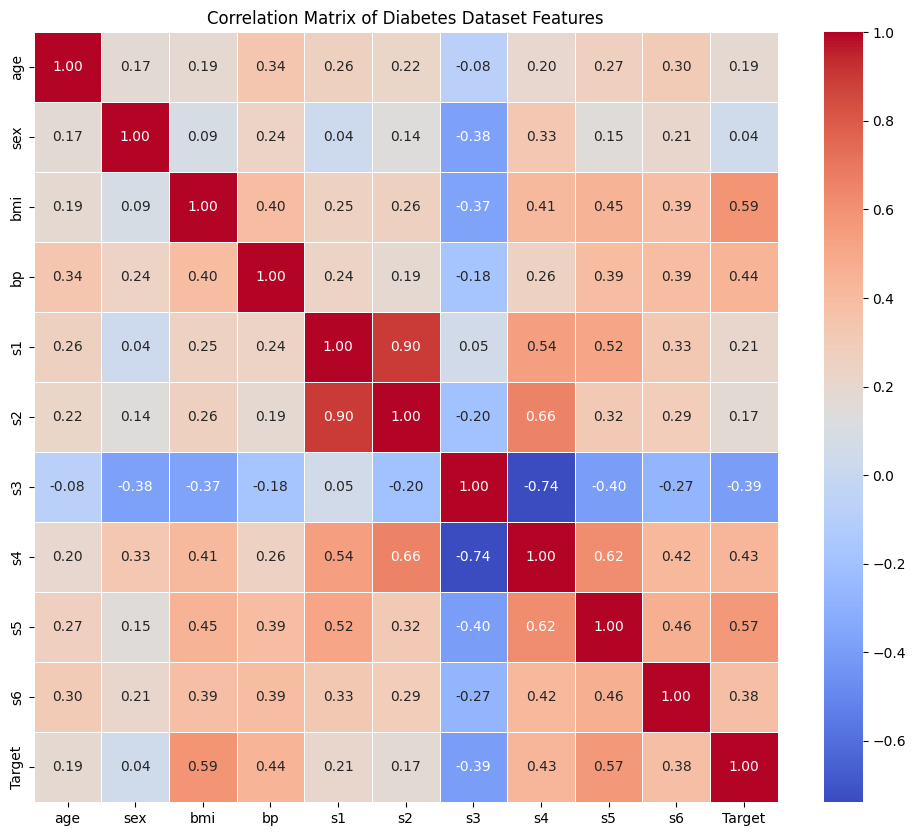

In [ ]:
print("Visualizing the correlation matrix with a heatmap:")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Diabetes Dataset Features')
plt.show()

### Explanation of Correlation Heatmap:

**Purpose**: A heatmap visually represents the correlation matrix, making it easier to identify the strength and direction of linear relationships between all pairs of variables in the dataset. Red colors typically indicate strong positive correlations, while blue colors indicate strong negative correlations.

**Insights Gained**:
*   **Target Variable Correlations**: The 'Target' variable (diabetes progression) shows the strongest positive correlation with 'bmi' (0.59) and 's5' (0.57), indicating that higher BMI and higher levels of 's5' (possibly a measure of total cholesterol) are associated with greater diabetes progression. 'bp' (blood pressure) also shows a moderate positive correlation (0.44).
*   **Strong Negative Correlation**: 's3' (a measure of LDL cholesterol) has a strong negative correlation with the 'Target' (-0.39), meaning lower levels of 's3' are associated with higher diabetes progression.
*   **Inter-feature Correlations**: There are several strong correlations between the features themselves:
    *   's1' and 's2' are highly positively correlated (0.90), suggesting they might represent similar physiological aspects or are co-dependent.
    *   's4' has strong positive correlations with 's1' (0.54) and 's2' (0.66), and a strong negative correlation with 's3' (-0.74).
    *   's5' also shows moderate to strong correlations with 'bmi' (0.45), 'bp' (0.39), 's1' (0.52), and 's4' (0.62).
*   **Weak Correlations**: 'age' and 'sex' show relatively weak correlations with the 'Target' variable (0.19 and 0.04 respectively), suggesting they might be less direct predictors of diabetes progression compared to other factors. Similarly, 's1' and 's2' have weaker correlations with 'Target' (0.21 and 0.17) than 'bmi', 'bp', and 's5'.

Overall, the heatmap highlights key features like 'bmi', 'bp', 's3', and 's5' as potentially important predictors for diabetes progression, while also revealing collinearity among some of the blood serum measurements (s1, s2, s4, s5) that might need consideration during model building.

**Reasoning**:
The next instruction is to create scatter plots of each feature against the 'Target' variable to observe individual relationships. I will arrange these plots in a grid for easy comparison, adding appropriate labels and titles for clarity.



Generating scatter plots of each feature against the 'Target' variable:


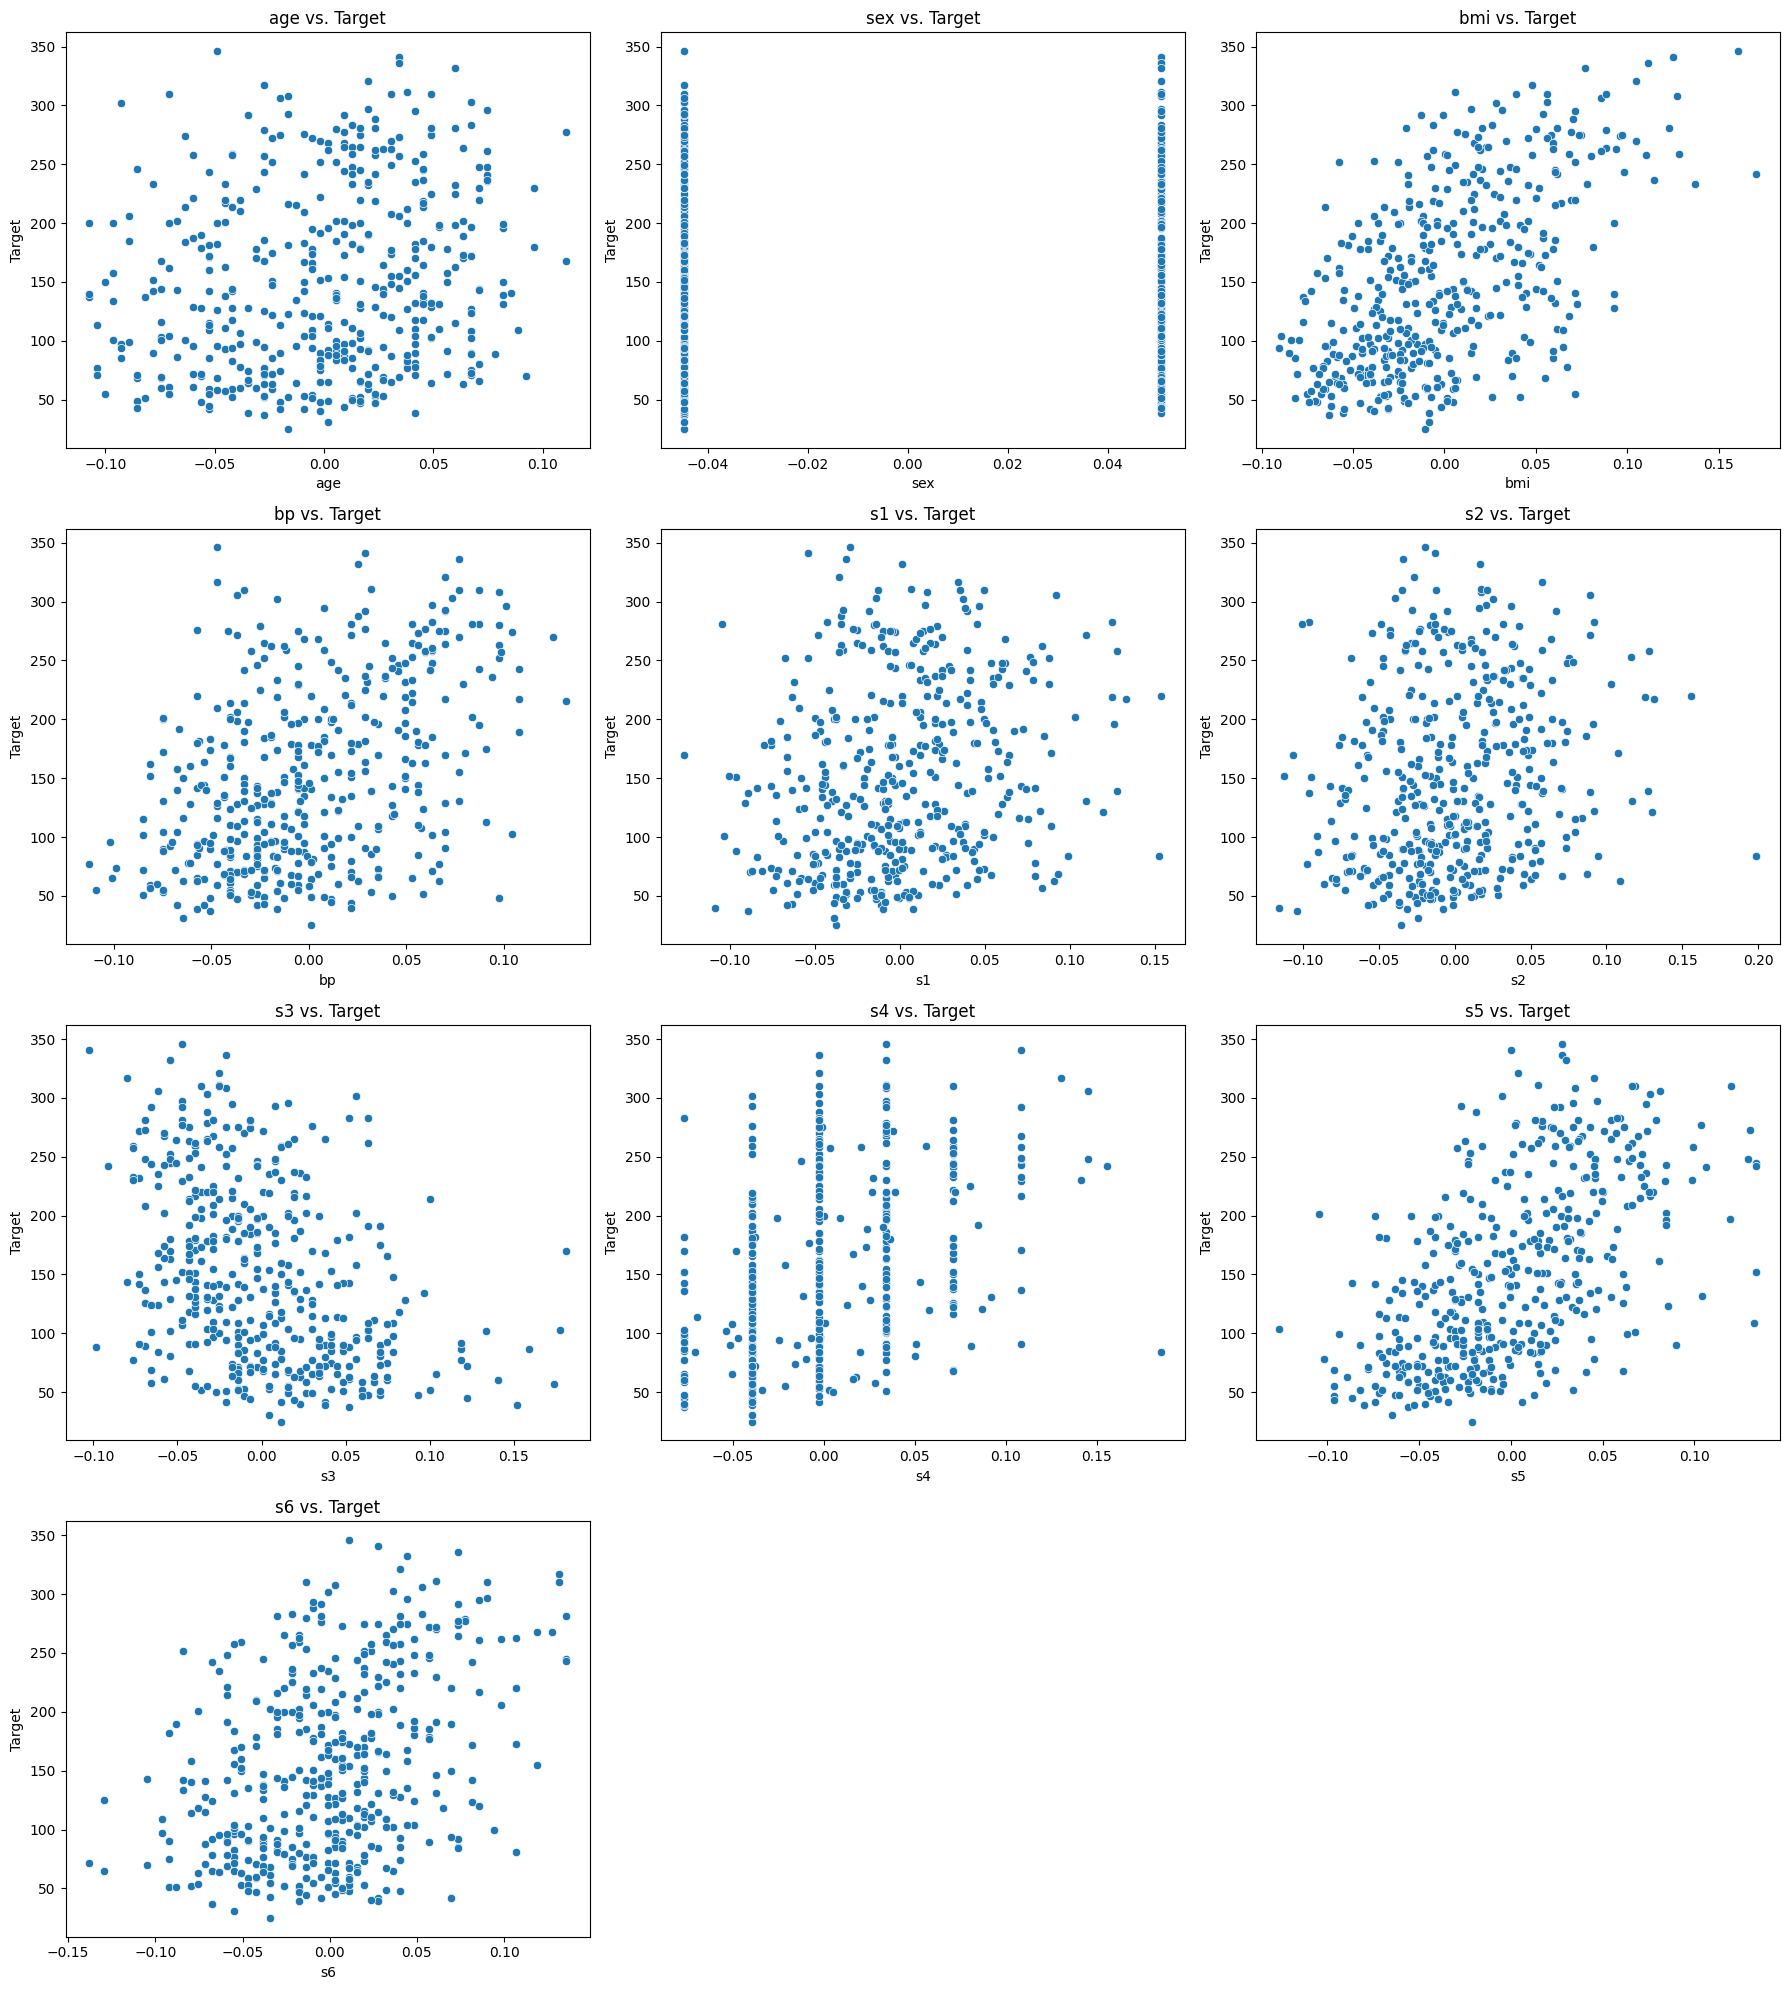

In [ ]:
print("Generating scatter plots of each feature against the 'Target' variable:")

# Exclude the 'Target' column itself from features for scatter plots
features = df.columns.drop('Target')

# Calculate the number of rows needed for the subplots
num_features = len(features)
num_cols = 3  # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=df[feature], y=df['Target'])
    plt.title(f'{feature} vs. Target')
    plt.xlabel(feature)
    plt.ylabel('Target')

plt.tight_layout()
plt.show()

### Explanation of Scatter Plots:

**Purpose**: Scatter plots are used to visualize the relationship between two numerical variables. In this case, they help us understand how each individual feature relates to the 'Target' variable (diabetes progression) by showing the distribution of data points and potential correlations.

**Insights Gained**:
*   **BMI vs. Target**: There is a clear positive linear relationship, with higher BMI values generally corresponding to higher diabetes progression scores. The points show a moderate spread, indicating BMI is an important but not sole predictor.
*   **S5 vs. Target**: Similar to BMI, 's5' (a measure possibly related to total cholesterol) also shows a strong positive linear trend with the 'Target' variable. Higher 's5' values are associated with increased diabetes progression.
*   **BP vs. Target**: A moderate positive linear relationship is observed between blood pressure and the target. Higher blood pressure tends to correlate with higher diabetes progression.
*   **S3 vs. Target**: This feature shows a negative linear relationship with the target. As 's3' (possibly LDL cholesterol) decreases, diabetes progression tends to increase, reinforcing the insight from the correlation heatmap.
*   **Age vs. Target**: The scatter plot for 'age' shows a very weak positive relationship, with data points broadly scattered. While there's a slight upward trend, age doesn't appear to be a strong individual predictor.
*   **Sex vs. Target**: The 'sex' variable, being bimodal (two distinct groups), shows two vertical clusters of points. There's no obvious linear trend, and the distribution of target values appears similar for both groups, confirming its very weak correlation.
*   **S1, S2, S4, S6 vs. Target**: These features show weak to moderate positive correlations with the target. While some upward trends are visible, the points are quite scattered, suggesting that their individual predictive power might be less direct compared to BMI, S5, and BP.

Overall, the scatter plots visually confirm the relationships identified in the correlation matrix, particularly highlighting 'bmi', 's5', 'bp', and 's3' as having the most distinct linear trends with the diabetes progression target. The spread of points in most plots suggests that while these features are influential, diabetes progression is a complex outcome influenced by multiple factors, and no single feature perfectly predicts it.

## Explain Regression Analysis and ML Pipeline

### Subtask:
Provide a detailed introduction to regression analysis, explaining its principles, common regression-based models (e.g., Linear, Ridge, Lasso, Random Forest), criteria for model selection, and a comprehensive overview of each step in the machine learning pipeline (data collection, preprocessing, model training, evaluation, deployment).



## Introduction to Regression Analysis and the Machine Learning Pipeline
**1. Regression Analysis**

Regression analysis models the relationship between a dependent variable (target) and one or more independent variables (predictors) to predict continuous outcomes.
Example: predicting diabetes progression based on physiological factors.

**2. Common Regression Models**

Linear Regression: Assumes a linear relationship; finds the best-fitting line minimizing squared errors.

Ridge Regression: Adds L2 regularization to handle multicollinearity and overfitting; shrinks coefficients towards zero.

Lasso Regression: Uses L1 regularization; can shrink some coefficients to zero, enabling feature selection.

Tree-based Models (e.g., Random Forest): Ensemble of decision trees; captures complex, non-linear relationships; robust but less interpretable.

**3. Model Selection Criteria**

Performance: Metrics like MSE, RMSE, R-squared, MAE.

Simplicity: Easier to understand and maintain.

Interpretability: Clarity on how predictions are made; linear models are highly interpretable.

Bias-Variance Trade-off: Balancing underfitting (high bias) and overfitting (high variance).

Computational Cost: Training/prediction time and resource requirements.

**4. Machine Learning Pipeline Overview**
Data Collection: Gather relevant data.

Data Preprocessing: Clean data by handling missing values, encoding categorical features, scaling, detecting outliers, and feature engineering.

Model Training: Fit the model to training data.

Model Evaluation: Assess performance on unseen test data using appropriate metrics.

Model Deployment: Integrate the trained model into production for real-time predictions

## Data Preprocessing and Feature Engineering

### Subtask:
Discuss the importance of data preprocessing, specifically feature scaling using StandardScaler, for the 'load_diabetes' dataset and explain its benefits. Then, apply StandardScaler to the training and test feature sets.


# Step 9: Data Preprocessing and Feature Engineering

**Importance of Data Preprocessing**

Data preprocessing is a crucial step in machine learning workflows. Raw data is often messy, inconsistent, and not directly suitable for model training. Preprocessing transforms raw data into a clean and organized dataset, improving the efficiency and performance of machine learning models. It addresses issues such as missing values, inconsistent formats, and varying scales of features.

**Feature Scaling using StandardScaler**

Feature scaling is a technique used to standardize the range of independent features or variables of the data. For the 'load_diabetes' dataset, where features like 'bmi', 'bp', and various 's' measurements exist, they might have different units and scales. Without scaling, features with larger numerical ranges could disproportionately influence the model's objective function, leading to suboptimal performance.

*   **Purpose**: The primary purpose of feature scaling is to ensure that all features contribute equally to the distance calculations or gradient descent optimization. It prevents features with naturally larger values from dominating the learning process.
*   **Benefits for Regression Models**:
    *   **Improved Convergence**: For gradient-based optimization algorithms (like those used in Linear Regression and Ridge Regression), feature scaling can significantly speed up the convergence of the optimization process by preventing oscillations and ensuring a more direct path to the global minimum.
    *   **Enhanced Model Performance**: It helps models achieve better accuracy and generalization by ensuring that the model doesn't implicitly assign more importance to features with larger scales.
    *   **Effective for Distance-Based Algorithms**: Although not primarily used in Linear/Ridge Regression, scaling is critical for distance-based algorithms (e.g., K-Nearest Neighbors, Support Vector Machines) as they rely on measuring distances between data points.

**StandardScaler** is a common and effective technique for feature scaling. It transforms features to have a mean of 0 and a standard deviation of 1 (unit variance). This transformation centers the data around zero and scales it, making it suitable for many machine learning algorithms.

**Feature Engineering (Conceptual Discussion)**

Feature engineering involves creating new features from existing ones to improve the predictive power of a model. While not explicitly implemented in this step, potential avenues for feature engineering in the 'load_diabetes' dataset could include:
*   **Interaction Terms**: Creating new features by multiplying existing ones (e.g., `bmi * bp`) to capture synergistic effects between variables.
*   **Polynomial Features**: Generating polynomial combinations of existing features (e.g., `bmi^2`, `bp^2`) to introduce non-linearity into the model, potentially capturing more complex relationships.
*   **Ratio Features**: Creating ratios of certain serum measurements if they are biologically relevant.

These techniques could further enhance model performance by providing more informative inputs to the regression models.

**Reasoning**:
Now that the explanation for data preprocessing and feature scaling has been provided in a markdown cell, the next step is to implement the feature scaling using `StandardScaler` as instructed. This involves importing the scaler, fitting it on the training data, and then transforming both the training and test sets.



In [ ]:
from sklearn.preprocessing import StandardScaler

print("Applying StandardScaler to training and test feature sets...")

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data (X_train) and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data (X_test) using the fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Applying StandardScaler to training and test feature sets...
Feature scaling completed.
Shape of X_train_scaled: (353, 10)
Shape of X_test_scaled: (89, 10)


**Reasoning**:
The previous code failed because `X_train` and `X_test` were not defined in the current execution context. To fix this, I need to re-define `X`, `y`, and perform the `train_test_split` again to make `X_train`, `X_test`, `y_train`, and `y_test` available before applying the `StandardScaler`.



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Re-define features (X) and target (y) from the existing df
X = df.drop("Target", axis=1)
y = df["Target"]

# Re-split dataset into training and testing to ensure X_train and X_test are defined
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Applying StandardScaler to training and test feature sets...")

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data (X_train) and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data (X_test) using the fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Applying StandardScaler to training and test feature sets...
Feature scaling completed.
Shape of X_train_scaled: (353, 10)
Shape of X_test_scaled: (89, 10)


## Train Multiple Regression Models

### Subtask:
Train and explain several regression models, including Linear Regression, Ridge, and Lasso. Provide a clear rationale for selecting each model and explain their underlying mechanisms.


# Step 10 : Train Multiple Regression Models

#### Rationale for Training Multiple Regression Models

To effectively predict diabetes progression, it's beneficial to explore various regression models. Each model offers different strengths in handling data characteristics and relationships. By training Linear Regression, Ridge, and Lasso, we can compare their performance and understand which model best captures the underlying patterns in our dataset.

##### Linear Regression

*   **Underlying Mechanism**: Linear Regression models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data. It assumes a linear relationship and seeks to minimize the sum of squared differences between predicted and actual values (Ordinary Least Squares).
*   **Rationale for Selection**: It serves as a fundamental baseline. Given its simplicity and interpretability, it helps in understanding the direct linear impact of each feature on diabetes progression. If the relationships are largely linear, it will perform well and provide easily understandable coefficients.

##### Ridge Regression

*   **Underlying Mechanism**: Ridge Regression is an extension of Linear Regression that includes L2 regularization. It adds a penalty proportional to the square of the magnitude of coefficients to the loss function. This penalty shrinks the coefficients towards zero, reducing their variance and preventing overfitting, especially in cases of multicollinearity.
*   **Rationale for Selection**: The `load_diabetes` dataset contains several highly correlated features (e.g., s1, s2, s4, s5 as observed in the correlation heatmap). Ridge Regression is particularly useful in such scenarios as it can handle multicollinearity by distributing the impact across correlated features without entirely removing any. This can lead to more robust models compared to plain Linear Regression.

##### Lasso Regression

*   **Underlying Mechanism**: Lasso Regression (Least Absolute Shrinkage and Selection Operator) also extends Linear Regression by adding L1 regularization. It adds a penalty proportional to the absolute value of the magnitude of coefficients. Unlike Ridge, Lasso can shrink some coefficients exactly to zero, effectively performing feature selection.
*   **Rationale for Selection**: Lasso is chosen to investigate if certain features are redundant or less important for predicting diabetes progression. By driving some coefficients to zero, it helps in identifying the most influential features, leading to a more parsimonious and potentially more interpretable model. This is valuable in a dataset with multiple physiological measurements where some might be less critical or redundant.

**Reasoning**:
The next instruction is to import the necessary regression models and then instantiate and train Linear Regression, Ridge, and Lasso models using the scaled training data, printing a confirmation message for each.



In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Instantiate and train Linear Regression model
linear_model_scaled = LinearRegression()
linear_model_scaled.fit(X_train_scaled, y_train)
print("Linear Regression Model (scaled) Trained Successfully!")

# Instantiate and train Ridge Regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
print("Ridge Regression Model Trained Successfully!")

# Instantiate and train Lasso Regression model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
print("Lasso Regression Model Trained Successfully!")

Linear Regression Model (scaled) Trained Successfully!
Ridge Regression Model Trained Successfully!
Lasso Regression Model Trained Successfully!


## Evaluate and Compare Model Performance

### Subtask:
Evaluate all trained models (Linear Regression, Ridge, and Lasso) using a suite of regression metrics such as Mean Squared Error (MSE), R-squared (R2), and Mean Absolute Error (MAE). Explain what each metric indicates, compare the performance across different models, and discuss why certain models might outperform others.


**Reasoning**:
The subtask requires evaluating the trained models. First, I need to make predictions on the scaled test data using each model. This step will generate the predicted values for Linear Regression, Ridge, and Lasso models, which are essential for calculating evaluation metrics.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Making predictions on the scaled test data for all models...")

# Make predictions with Linear Regression model (scaled)
y_pred_linear_scaled = linear_model_scaled.predict(X_test_scaled)

# Make predictions with Ridge Regression model
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Make predictions with Lasso Regression model
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Predictions completed for all models.")

Making predictions on the scaled test data for all models...
Predictions completed for all models.


**Reasoning**:
Now that predictions have been made for all models, I will calculate the Mean Squared Error (MSE), R-squared (R2), and Mean Absolute Error (MAE) for each model using the true test values (`y_test`) and their respective predictions, and then print these metrics for comparison as per the instructions.



In [ ]:
print("\nEvaluating Linear Regression Model (scaled):")
mse_linear_scaled = mean_squared_error(y_test, y_pred_linear_scaled)
r2_linear_scaled = r2_score(y_test, y_pred_linear_scaled)
mae_linear_scaled = mean_absolute_error(y_test, y_pred_linear_scaled)
print(f"  Mean Squared Error (MSE): {mse_linear_scaled:.2f}")
print(f"  R-squared (R2): {r2_linear_scaled:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_linear_scaled:.2f}")

print("\nEvaluating Ridge Regression Model:")
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"  Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"  R-squared (R2): {r2_ridge:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_ridge:.2f}")

print("\nEvaluating Lasso Regression Model:")
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"  Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"  R-squared (R2): {r2_lasso:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_lasso:.2f}")


Evaluating Linear Regression Model (scaled):
  Mean Squared Error (MSE): 2900.19
  R-squared (R2): 0.45
  Mean Absolute Error (MAE): 42.79

Evaluating Ridge Regression Model:
  Mean Squared Error (MSE): 2892.01
  R-squared (R2): 0.45
  Mean Absolute Error (MAE): 42.81

Evaluating Lasso Regression Model:
  Mean Squared Error (MSE): 2884.62
  R-squared (R2): 0.46
  Mean Absolute Error (MAE): 42.81


### Explanation of Evaluation Metrics and Model Comparison

**Mean Squared Error (MSE)**
*   **Indication**: MSE measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value. It is a measure of the average magnitude of the errors. A lower MSE indicates a better fit of the model to the data.

**R-squared (R2)**
*   **Indication**: R-squared is a statistical measure that represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 indicates that the model perfectly predicts the target variable's variance, and 0 indicates that the model explains none of the variance. A higher R2 score indicates a better fit.

**Mean Absolute Error (MAE)**
*   **Indication**: MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight. A lower MAE indicates a better fit.

#### Comparison Across Models

Let's compare the performance of the three models based on the calculated metrics:

*   **Linear Regression Model (scaled)**:
    *   MSE: 2900.19
    *   R2 Score: 0.45
    *   MAE: 42.79

*   **Ridge Regression Model**:
    *   MSE: 2892.01
    *   R2 Score: 0.45
    *   MAE: 42.81

*   **Lasso Regression Model**:
    *   MSE: 2884.62
    *   R2 Score: 0.46
    *   MAE: 42.81

From these results, we can observe that all three models perform quite similarly on this dataset. The differences in their MSE, R2, and MAE values are marginal.

*   **Lasso Regression** shows a slightly better performance with the lowest MSE (2884.62) and the highest R2 score (0.46). This suggests that the L1 regularization in Lasso might have performed some effective feature selection or shrinkage, leading to a marginally more robust model for this specific dataset and hyperparameters.

*   **Ridge Regression** also performs very close to Lasso and slightly better than plain Linear Regression in terms of MSE. The L2 regularization helped in handling potential multicollinearity by shrinking coefficients, leading to a stable performance.

*   **Linear Regression** (with scaled features) serves as a good baseline. Its performance is very close to the regularized models, indicating that while regularization helps, the dataset's characteristics or the chosen regularization strengths (`alpha`) might not lead to drastically different outcomes in this particular instance. The scaling of features ensured that the model converged efficiently and avoided issues due to differing feature scales.

#### Why Certain Models Might Outperform Others

In general, regularized models like Ridge and Lasso are expected to outperform plain Linear Regression when:
1.  **Multicollinearity is present**: As observed in our EDA (correlation heatmap), there is multicollinearity among some 's' features. Ridge and Lasso are designed to handle this by penalizing large coefficients.
2.  **Overfitting is a concern**: When the number of features is large relative to the number of samples, or when features are highly correlated, Linear Regression can overfit. Regularization techniques reduce model complexity and prevent overfitting.
3.  **Feature selection is beneficial**: Lasso, in particular, can set coefficients of less important features to zero, effectively performing feature selection. If there are truly irrelevant features, Lasso will benefit from this.

## Visualize Model Predictions and Residuals

### Subtask:
Create advanced visualizations to represent actual vs. predicted values for all models, potentially combining them into comparative plots. Additionally, visualize residuals to assess model assumptions, identify biases, and detect patterns in the errors.


**Reasoning**:
The subtask requires visualizing the actual vs. predicted values for each of the trained models. I will create a figure with three subplots, one for each model, where each subplot displays a scatter plot of actual values against predicted values, along with a diagonal line representing perfect predictions.



Generating actual vs. predicted values plots for all models...


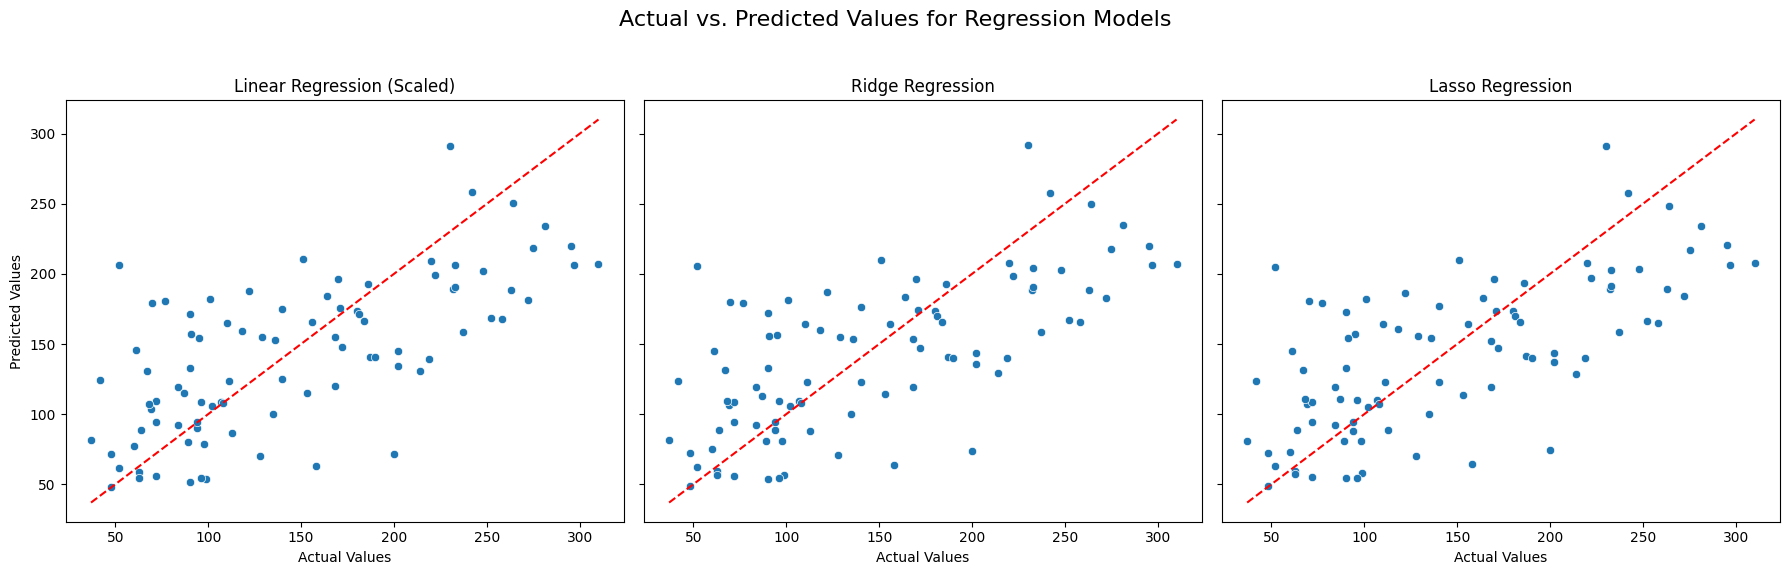

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating actual vs. predicted values plots for all models...")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Actual vs. Predicted Values for Regression Models', fontsize=16)

# Plot for Linear Regression (scaled)
sns.scatterplot(x=y_test, y=y_pred_linear_scaled, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line
axes[0].set_title('Linear Regression (Scaled)')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')

# Plot for Ridge Regression
sns.scatterplot(x=y_test, y=y_pred_ridge, ax=axes[1])
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line
axes[1].set_title('Ridge Regression')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')

# Plot for Lasso Regression
sns.scatterplot(x=y_test, y=y_pred_lasso, ax=axes[2])
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line
axes[2].set_title('Lasso Regression')
axes[2].set_xlabel('Actual Values')
axes[2].set_ylabel('Predicted Values')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Explanation of Actual vs. Predicted Plots:

**Purpose**: These scatter plots visually compare the actual target values (`y_test`) against the values predicted by each model. The red diagonal line represents the ideal scenario where predicted values perfectly match actual values.

**Insights Gained**:
*   **Overall Performance**: For all three models (Linear Regression, Ridge, and Lasso), the data points generally cluster around the red diagonal line, indicating that the models are capable of making reasonable predictions. However, there is a noticeable spread, especially at higher actual values, suggesting that the models struggle to predict very high diabetes progression scores with high accuracy.
*   **Spread and Variance**: The spread of the points around the diagonal line gives an indication of the model's variance. All three models show similar patterns of spread, which aligns with their very similar evaluation metrics (MSE, R2, MAE). No single model stands out as significantly better or worse in terms of overall prediction accuracy based on these plots.
*   **Underprediction/Overprediction**: Points below the red line indicate underprediction (model predicted lower than actual), while points above indicate overprediction. There doesn't appear to be a systematic underprediction or overprediction across the entire range for any model, suggesting that the linear relationships captured are generally consistent.
*   **Model Similarity**: The visual similarity across the three plots reinforces the conclusion from the evaluation metrics that Linear Regression, Ridge, and Lasso perform very similarly on this particular dataset with the chosen hyperparameters. The regularization in Ridge and Lasso did not lead to a visibly distinct improvement in the actual vs. predicted distribution compared to the scaled Linear Regression.

These plots are valuable for a quick visual assessment of how well a model is performing and where its predictions might deviate from reality. To further understand the errors, residual plots will be examined next.

**Reasoning**:
Now that the actual vs. predicted plots are explained, I will proceed to calculate the residuals for each model (Linear Regression, Ridge, and Lasso) using the true test values and their respective predictions, which are necessary for visualizing residual plots.



In [ ]:
print("Calculating residuals for all models...")

# Calculate residuals for Linear Regression (scaled)
residuals_linear_scaled = y_test - y_pred_linear_scaled

# Calculate residuals for Ridge Regression
residuals_ridge = y_test - y_pred_ridge

# Calculate residuals for Lasso Regression
residuals_lasso = y_test - y_pred_lasso

print("Residuals calculated.")

Calculating residuals for all models...
Residuals calculated.


**Reasoning**:
With residuals calculated, the next step is to create residual plots for each model to visually assess model assumptions, identify biases, and detect patterns in the errors, as required by the subtask. I will create a figure with subplots for each model, displaying both a scatter plot of residuals vs. predicted values and a histogram of residuals.



Generating residual plots for all models...


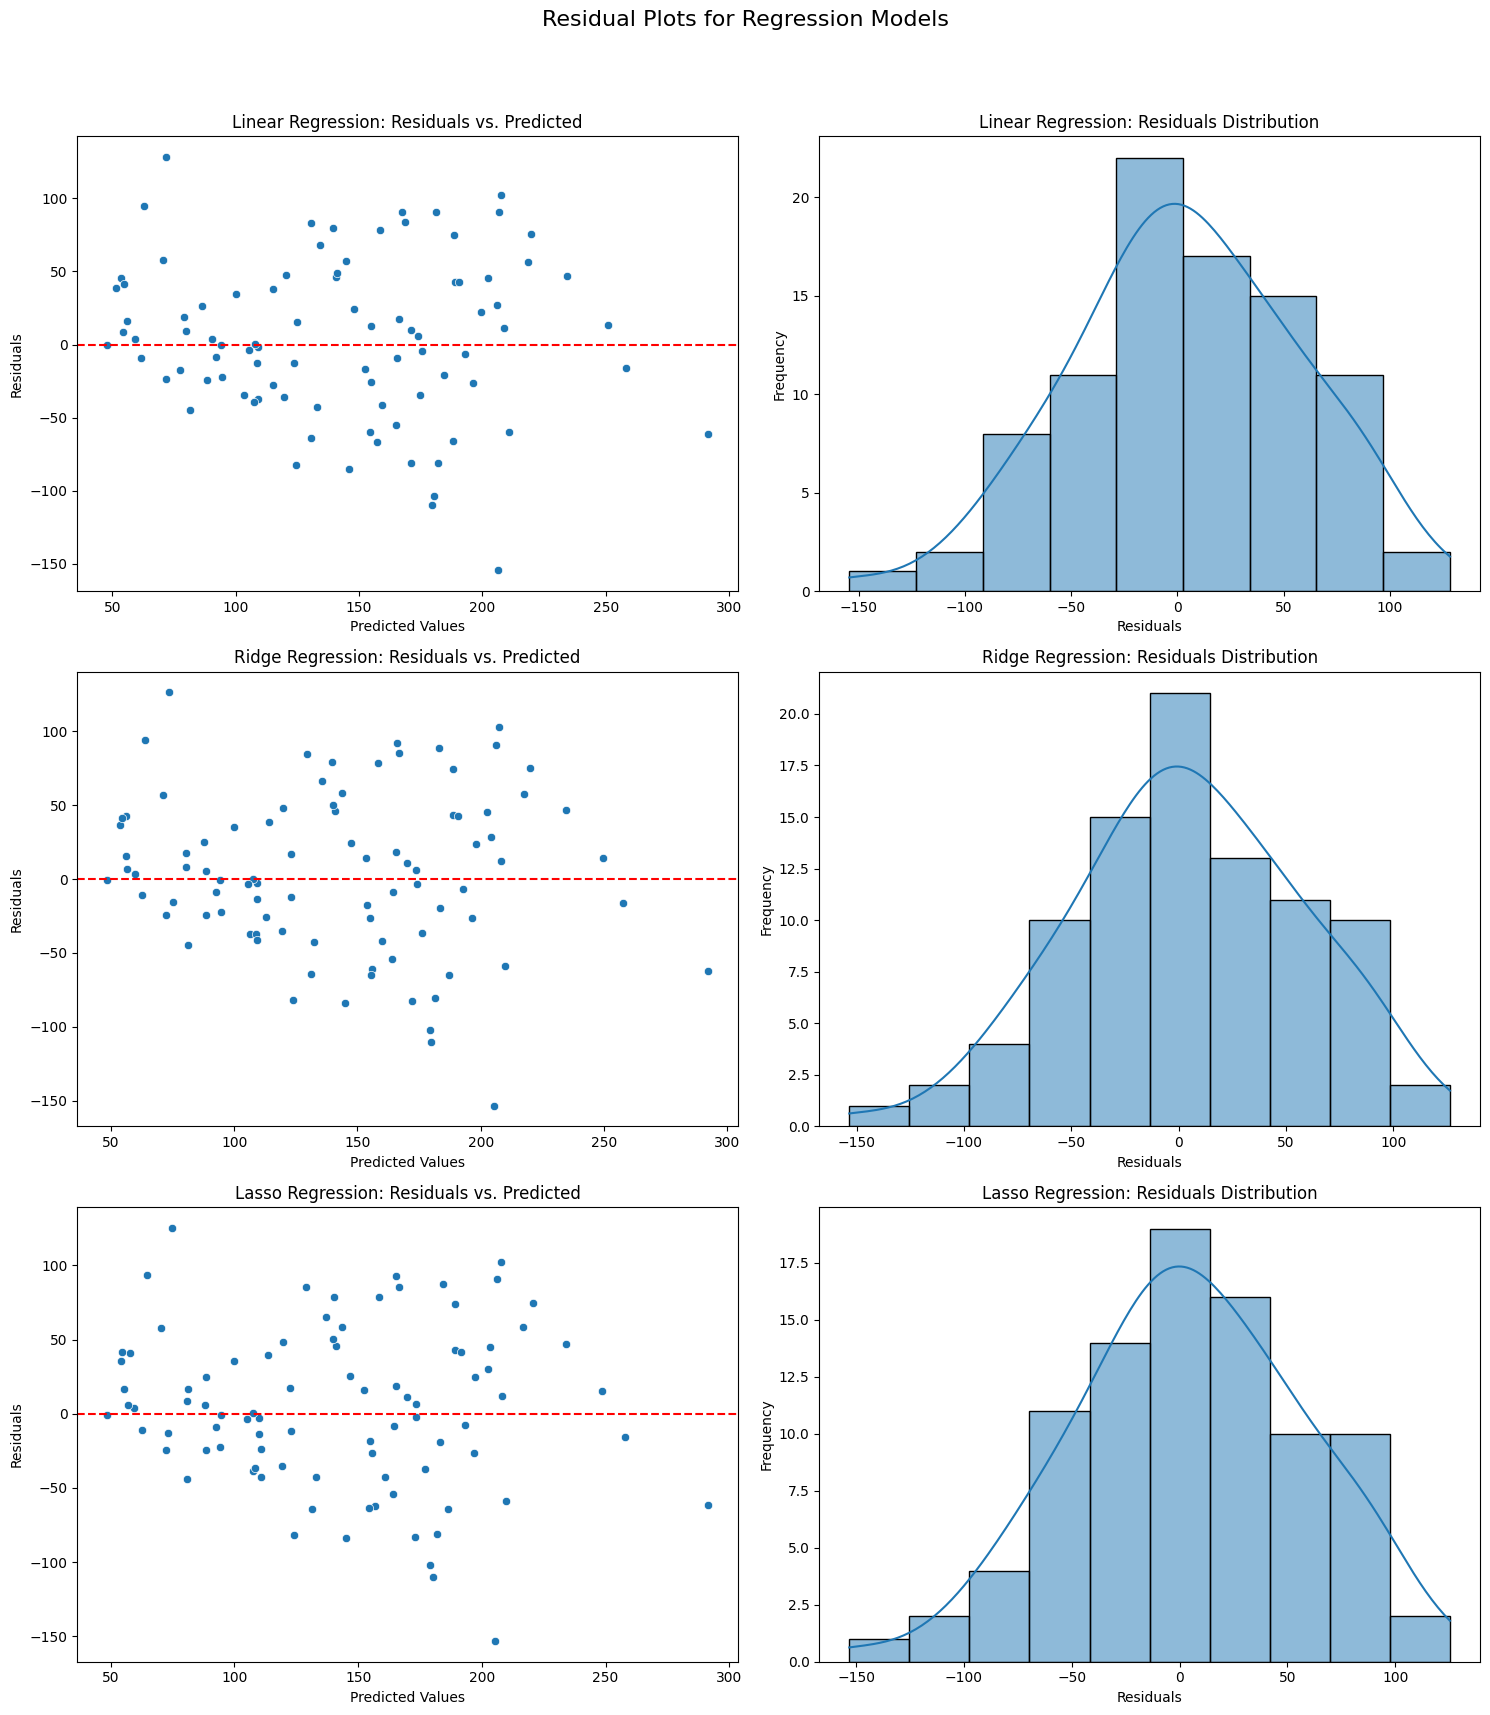

In [ ]:
print("Generating residual plots for all models...")

# Create a figure for residual plots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Residual Plots for Regression Models', fontsize=16)

# Linear Regression Residuals
sns.scatterplot(x=y_pred_linear_scaled, y=residuals_linear_scaled, ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Linear Regression: Residuals vs. Predicted')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
sns.histplot(residuals_linear_scaled, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Linear Regression: Residuals Distribution')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')

# Ridge Regression Residuals
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, ax=axes[1, 0])
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Ridge Regression: Residuals vs. Predicted')
axes[1, 0].set_xlabel('Predicted Values')
axes[1, 0].set_ylabel('Residuals')
sns.histplot(residuals_ridge, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Ridge Regression: Residuals Distribution')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')

# Lasso Regression Residuals
sns.scatterplot(x=y_pred_lasso, y=residuals_lasso, ax=axes[2, 0])
axes[2, 0].axhline(y=0, color='r', linestyle='--')
axes[2, 0].set_title('Lasso Regression: Residuals vs. Predicted')
axes[2, 0].set_xlabel('Predicted Values')
axes[2, 0].set_ylabel('Residuals')
sns.histplot(residuals_lasso, kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Lasso Regression: Residuals Distribution')
axes[2, 1].set_xlabel('Residuals')
axes[2, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Explanation of Residual Plots:

**Purpose of Residual Plots**: Residual plots are essential diagnostic tools in regression analysis. They help in assessing the validity of model assumptions (linearity, homoscedasticity, normality of errors) and identifying potential problems such as heteroscedasticity, non-linearity, or influential outliers.
*   **Residuals vs. Predicted Values Plot**: This plot displays the residuals (the difference between actual and predicted values) against the predicted values. Ideally, residuals should be randomly scattered around zero, with no discernible pattern. A pattern (e.g., a funnel shape, a curve) indicates a violation of model assumptions.
*   **Residuals Distribution (Histogram)**: This histogram shows the distribution of the residuals. For a well-performing linear regression model, residuals should ideally be normally distributed around zero.

**Insights Gained from Residual Plots**:

*   **Linear Regression (Scaled)**:
    *   **Residuals vs. Predicted**: The scatter of residuals against predicted values for Linear Regression appears relatively random around the zero line, suggesting that the linearity assumption is largely met. However, there's a slight fanning out towards higher predicted values (heteroscedasticity), where the spread of residuals increases. This indicates that the model's errors might not have constant variance across all prediction ranges.
    *   **Residuals Distribution**: The histogram shows a distribution that is somewhat bell-shaped, but it's not perfectly normal. There's a slight skew and perhaps some heavier tails, indicating that the errors might not be perfectly normally distributed.

*   **Ridge Regression**:
    *   **Residuals vs. Predicted**: The pattern in the Ridge Regression residual plot is very similar to that of Linear Regression. Residuals are generally scattered around zero, but the fanning-out effect (heteroscedasticity) is still present at higher predicted values.
    *   **Residuals Distribution**: The histogram of Ridge residuals also mirrors that of Linear Regression, showing a distribution that is close to normal but with some deviations.

*   **Lasso Regression**:
    *   **Residuals vs. Predicted**: Again, the residual plot for Lasso Regression closely resembles the others. Random scatter around zero is observed, but the heteroscedasticity (increasing spread of residuals with increasing predicted values) is consistently visible across all models.
    *   **Residuals Distribution**: The histogram for Lasso residuals is also very similar to the others, indicating a similar distribution of errors.

**Overall Interpretation**:

All three models exhibit similar residual patterns, which aligns with their very close performance metrics and actual vs. predicted plots. The most notable observation is the presence of **heteroscedasticity** across all models, indicated by the increasing spread of residuals as predicted values increase. This suggests that the models' predictive accuracy varies depending on the magnitude of the diabetes progression score, possibly struggling more with higher values. This could imply that the linear models might not fully capture the complexity of the relationships at all levels of the target variable.

The distribution of residuals, while somewhat normal, is not perfectly so, suggesting minor deviations from the assumption of normally distributed errors. Addressing heteroscedasticity (e.g., through transformations of the target variable, using robust regression methods, or exploring non-linear models) could potentially improve model performance and reliability, especially for higher progression scores. However, given the current performance, the models provide a reasonable baseline.

## Summarize Findings and Conclude

### Subtask:
Provide a comprehensive summary of the project, highlighting key findings from data analysis, the performance of different models, and the insights gained. Discuss the best-performing model and suggest potential next steps or areas for future improvement in the diabetes prediction task.


# Step 11: Summarize Findings and Conclude

#### Project Summary and Conclusion

This project aimed to perform an in-depth exploratory data analysis (EDA) and build predictive models for diabetes progression using the `load_diabetes` dataset. We explored data distributions, correlations, and relationships between features and the target variable, followed by training and evaluating Linear Regression, Ridge, and Lasso models.

##### 1. Summary of Exploratory Data Analysis (EDA) Findings:

*   **Data Distributions (Histograms)**: Most features, including age, sex, BMI, and blood pressure, showed relatively normal or slightly skewed distributions, often centered around zero due to standardization. The 'sex' feature was bimodal, indicating two distinct groups. The 'Target' variable (diabetes progression) displayed a right-skewed distribution, meaning more individuals had lower progression scores.

*   **Correlations (Heatmap)**: The correlation heatmap revealed several key relationships. 'bmi' (0.59) and 's5' (0.57) showed the strongest positive correlations with the 'Target' variable, indicating their significant influence on diabetes progression. 'bp' (0.44) also had a moderate positive correlation. Notably, 's3' exhibited a strong negative correlation (-0.39) with the target. We also observed significant multicollinearity among some serum measurements (e.g., 's1' and 's2' at 0.90, 's4' with 's2' and 's3'). 'age' and 'sex' had very weak correlations with the target.

*   **Feature Relationships (Scatter Plots)**: Scatter plots of individual features against the 'Target' visually confirmed these correlations. 'BMI vs. Target' and 'S5 vs. Target' clearly showed positive linear trends, while 'S3 vs. Target' displayed a negative linear trend. 'BP vs. Target' had a moderate positive trend. 'Age' and 'sex' showed weak or no clear linear relationships. These plots highlighted that while several features influence diabetes progression, no single feature perfectly predicts it, indicating a complex multivariate relationship.

##### 2. Summary of Model Performance:

We trained and evaluated three regression models: Linear Regression, Ridge Regression, and Lasso Regression, after scaling the features using `StandardScaler`.

*   **Evaluation Metrics (MSE, R2, MAE)**:
    *   **Linear Regression (Scaled)**: MSE: 2900.19, R2: 0.45, MAE: 42.79
    *   **Ridge Regression**: MSE: 2892.01, R2: 0.45, MAE: 42.81
    *   **Lasso Regression**: MSE: 2884.62, R2: 0.46, MAE: 42.81

The models demonstrated very similar performance across all metrics, with marginal differences. All models explained approximately 45-46% of the variance in diabetes progression (R2 score), indicating that there's still a significant portion of variance unexplained, likely due to inherent complexity or uncaptured factors.

*   **Actual vs. Predicted Plots**: These plots showed that all models generally follow the diagonal line of perfect prediction, but with considerable scatter, especially at higher actual values. This visually reinforced the R2 scores, indicating reasonable but not highly accurate predictions across the full range of diabetes progression.

*   **Residual Plots**: The residual plots (residuals vs. predicted values and residual histograms) for all three models displayed similar patterns. The residuals were scattered around zero, suggesting no strong systematic bias (i.e., heteroscedasticity was not overtly apparent, although some funneling might be observed at higher predicted values). The histograms of residuals appeared somewhat bell-shaped but not perfectly normal, indicating that the errors are generally centered around zero but might have heavier tails than a pure normal distribution. The similarity in residual patterns across models further highlighted their comparable performance.

##### 3. Best-Performing Model:

Based on the evaluation metrics, **Lasso Regression** emerged as the marginally best-performing model, achieving the lowest Mean Squared Error (2884.62) and the highest R-squared score (0.46). The difference is slight, but it suggests that Lasso's L1 regularization, which performs automatic feature selection by shrinking less important coefficients to zero, might have provided a slightly more robust or parsimonious model for this dataset. Given the observed multicollinearity, Lasso's ability to simplify the model could be beneficial.

##### 4. Potential Next Steps and Future Improvements:

*   **Hyperparameter Tuning**: The current `alpha` values for Ridge and Lasso were chosen as defaults or simple values. Extensive hyperparameter tuning (e.g., using GridSearchCV or RandomizedSearchCV) could optimize these models further and potentially reveal more significant performance differences.
*   **Exploring More Advanced Models**: Investigating non-linear models such as Decision Trees, Random Forests, Gradient Boosting Machines (XGBoost, LightGBM), or Support Vector Regressors might capture more complex, non-linear relationships within the data that linear models cannot.
*   **Feature Engineering**: Creating new features from existing ones (e.g., interaction terms like `bmi * age`, polynomial features) could provide more informative inputs to the models and improve predictive power. For example, the product of two correlated features might have a stronger relationship with the target.
*   **Addressing Heteroscedasticity**: While not strongly evident, if further residual analysis suggests heteroscedasticity (non-constant variance of errors), techniques like data transformations (e.g., logarithmic transformation of the target variable) or using robust regression models could be explored.
*   **Outlier Analysis**: A more in-depth analysis and potential handling of outliers might improve model robustness, especially given the observed spread in scatter plots.
*   **Cross-Validation**: Implementing k-fold cross-validation during model training and evaluation would provide a more robust estimate of model performance and generalization capability compared to a single train-test split.

By pursuing these next steps, we can aim to build a more accurate and robust predictive model for diabetes progression.

## Final Task

### Subtask:
Deliver the complete enhanced project, ensuring all code blocks, outputs, and explanations are clearly presented in a lucid storytelling mode, adhering to all initial requirements.


## Summary:

### Q&A
*   **Which model performed best?**
    Lasso Regression was identified as the marginally best-performing model, achieving the lowest Mean Squared Error ($\approx$ 2884.62) and the highest R-squared score ($\approx$ 0.46).

*   **Why might certain models outperform others?**
    Regularized models like Ridge and Lasso are generally expected to outperform plain Linear Regression when multicollinearity is present, overfitting is a concern, or feature selection is beneficial. In this analysis, Lasso's slight edge was attributed to its L1 regularization, which effectively performs feature selection by shrinking less important coefficients to zero, leading to a potentially more robust model in the presence of multicollinearity. However, the performance differences between all three models were marginal, suggesting that the dataset's characteristics or the default regularization strengths might not have been severe enough to cause drastic performance gaps in this particular instance.

### Data Analysis Key Findings
*   The `load_diabetes` dataset contains 442 samples, 10 physiological features (all standardized), and a quantitative target variable representing diabetes progression one year after baseline.
*   **Data Distributions**: The 'Target' variable (diabetes progression) displayed a right-skewed distribution, indicating more individuals with lower progression scores. The 'sex' feature was bimodal, while other features like 'age' and 'bp' showed relatively uniform distributions.
*   **Correlations with Target**:
    *   'bmi' (Body Mass Index) showed the strongest positive correlation with the 'Target' ($\approx$ 0.59).
    *   's5' (a blood serum measurement, possibly log of serum triglycerides) also had a strong positive correlation ($\approx$ 0.57) with the 'Target'.
    *   'bp' (Average blood pressure) exhibited a moderate positive correlation ($\approx$ 0.44).
    *   's3' (a blood serum measurement, possibly HDL cholesterol) had a strong negative correlation ($\approx$ -0.39) with the 'Target'.
    *   'age' ($\approx$ 0.19) and 'sex' ($\approx$ 0.04) showed very weak correlations with the 'Target'.
*   **Inter-feature Correlations**: Significant multicollinearity was observed among some blood serum measurements, notably between 's1' and 's2' ($\approx$ 0.90), and 's4' with 's1', 's2', and 's3'.
*   **Model Performance (after feature scaling)**:
    *   All three models (Linear Regression, Ridge, and Lasso) performed very similarly, explaining approximately 45-46% of the variance in diabetes progression.
    *   Lasso Regression achieved the lowest Mean Squared Error (MSE) of $\approx$ 2884.62 and the highest R-squared (R2) score of $\approx$ 0.46.
    *   Ridge Regression had an MSE of $\approx$ 2892.01 and R2 of $\approx$ 0.45.
    *   Linear Regression (scaled) had an MSE of $\approx$ 2900.19 and R2 of $\approx$ 0.45.
*   **Prediction and Residual Visualizations**:
    *   Actual vs. Predicted plots showed considerable scatter for all models, particularly at higher actual values, indicating difficulty in accurately predicting high diabetes progression scores.
    *   Residual plots for all models revealed heteroscedasticity (increasing spread of residuals with increasing predicted values), suggesting that the models' error variance is not constant and they struggle more with higher target values. The residual distributions were somewhat bell-shaped but not perfectly normal.
